# **Project Name: Mental Health in Tech Survey - Policy Benchmarking Analysis**
**Project Type:** Exploratory Data Analysis (EDA)  
**Contribution:** Individual

## **Project Summary**

The Open Sourcing Mental Illness (OSMI) 2014 Mental Health in Tech Survey serves as a foundational dataset examining workplace attitudes, institutional mental health provisions, and individual health-seeking behaviors across the global technology sector. As competitive tech enterprises increasingly recognize employee well-being as a cornerstone of talent retention, productivity, and organizational resilience, executive leadership requires empirical baselines against which to benchmark internal corporate benefits, HR policies, and psychological safety standards. This project conducts an exhaustive Exploratory Data Analysis (EDA) specifically framed from the perspective of an employer benchmarking its mental health support infrastructure against international and intra-industry peer patterns.

The raw dataset comprises 1,259 individual survey responses spanning 27 variables, capturing demographic identifiers (age, gender, country, US state), employment parameters (company headcount, remote working arrangements, self-employment status), organizational offerings (formal benefits, wellness programs, care option awareness, anonymity protections, medical leave accessibility), and cultural perceptions (fear of career consequences, openness with supervisors and peers, and willingness to disclose during hiring interviews). To establish high-integrity analytical baselines, a rigorous, reproducible data-wrangling pipeline was constructed. Erroneous and implausible age entries (ranging from negative figures such as -1,728 up to 99,999,999,999) were filtered to a valid working-age cohort of 18 to 75 years, removing exactly 8 invalid records. Free-text gender responses exhibited significant fragmentation; an explicit canonical mapping harmonized diverse self-identifications into three robust operational groups: Male (78.02%), Female (19.58%), and Other / Non-Binary (2.40%). Country names were normalized, and state entries were strictly restricted to United States respondents. Notably, structural null values in work interference (20.94%), self-employment (1.44%), and open commentary (86.89%) were deliberately preserved rather than imputed, as their absence reflects meaningful survey branch logic (such as respondents without diagnosed mental conditions) rather than missing data flaws.

Exploratory analysis of the cleaned 1,251-record cohort surfaced four paramount empirical benchmarks:
First, a dramatic **Mental vs. Physical Stigma Disparity** persists across tech workplaces. While 73.54% of tech workers feel confident that discussing a physical health issue will not produce negative career consequences, only 38.93% share that certainty regarding mental health—reflecting a nearly fivefold elevation in perceived consequence risk (23.02% mental vs. 4.64% physical). This stigma compounds acutely during recruitment, where 80.18% of workers refuse to disclose a mental health condition during job interviews (compared to only 39.65% for physical conditions).
Second, individual clinical and genetic indicators—specifically **family history of mental illness** (74.03% treatment rate vs. 35.43% without) and **work interference severity** (85.00% treatment rate among those reporting 'Often' interference vs. 14.15% for 'Never')—represent the dominant statistical drivers of treatment seeking, exerting far stronger predictive influence than company size or demographic factors.
Third, substantial **Geographic Variation** exists across sovereign healthcare ecosystems and US regional clusters. International treatment rates range from 61.90% in Australia and 54.69% in the United States down to 33.33% in the Netherlands, while US state rates vary from ~70% in Ohio and Illinois to 40.00% in Tennessee, underscoring the necessity for geographically tiered benefit designs.
Fourth, counter to common assumptions, **Remote Work Arrangements** do not engender disclosure isolation; remote personnel demonstrate equal or slightly higher willingness to discuss mental health with direct managers (43.86% vs. 39.65%) and peers (22.11% vs. 15.89%) compared to non-remote colleagues.

Together, these findings provide corporate leadership with actionable benchmarks to audit benefit awareness, bridge institutional stigma chasms, and operationalize proactive psychological safety initiatives.

## **GitHub Link**
https://github.com/JDMalkerion/mental-health-tech-survey
## **Live Demo:** 
https://mental-health-tech-survey-gujdvph8mrjmyygqexj8pd.streamlit.app/

## **Problem Statement**

In the modern technology industry, mental health challenges represent a major driver of employee burnout, voluntary attrition, and diminished workplace engagement. Despite expanding corporate investments in Employee Assistance Programs (EAPs) and wellness perks, business leaders and People Operations teams frequently lack empirical, industry-wide benchmarks to evaluate whether their mental health offerings are truly effective or merely performative. 

Without standardized comparative data, employers cannot accurately assess:
1. Whether their employee treatment and diagnosis rates reflect healthy benefit utilization or unaddressed systemic distress.
2. How workplace psychological safety and disclosure comfort compare across different company sizes, global headquarters, and remote or hybrid work structures.
3. The degree to which lingering stigma deters employees from seeking care before work interference impacts team performance.

By analyzing the OSMI Mental Health in Tech Survey, this analysis establishes an empirical reference baseline for tech employers to benchmark their support policies, identify coverage gaps, and design evidence-based human capital interventions.

## **Business Objective**

The primary objective of this benchmarking analysis is to empower tech leaders, HR executives, and benefits administrators with quantitative metrics on employee treatment-seeking behaviors, institutional care awareness, and cultural stigma across peer organizations. By benchmarking against industry patterns across company sizes (from 1-5 person startups to enterprises with 1,000+ staff), international regulatory regimes (US, UK, Canada, Australia, Germany, Netherlands), and distributed work models, employers can pinpoint where their internal policies under- or over-perform. The resulting insights enable organizations to optimize benefits communication, train supervisors as effective first-line allies, eliminate perceived career penalties for seeking care, and cultivate an open culture that attracts and retains top-tier technical talent.

## **Know Your Data**

### 1. Import Libraries
We begin by importing the standard data manipulation, statistical analysis, and visualization libraries. All chart styling is set to clean, publication-ready defaults.

In [ ]:
# Import standard data analysis and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

# Color constants for consistent visual hierarchy
COLOR_PRIMARY = '#2A7B88'     # Deep teal (treatment / mental health)
COLOR_SECONDARY = '#E07A5F'   # Coral / amber (physical health / comparison)
COLOR_NEUTRAL = '#81B29A'     # Sage green (support / yes)
COLOR_SLATE = '#5B6478'       # Slate gray (baseline / no)
COLOR_ALERT = '#D9534F'       # Red / alert (high stigma / fear)

print("Libraries imported and visualization styling configured successfully.")

Libraries imported and visualization styling configured successfully.


### 2. Load Dataset
We load the raw 2014 OSMI Mental Health in Tech Survey dataset from `data/survey.csv`.

In [ ]:
# Load raw survey dataset
try:
    df_raw = pd.read_csv('data/survey.csv')
except FileNotFoundError:
    # Alternative path if executed from another working directory
    df_raw = pd.read_csv('survey.csv')

print(f"Dataset successfully loaded. Total rows: {df_raw.shape[0]:,}, Total columns: {df_raw.shape[1]}")

Dataset successfully loaded. Total rows: 1,259, Total columns: 27


### 3. Dataset First View (.head())
Preview the initial 5 rows of the raw dataset.

In [ ]:
# Display the first 5 rows of the raw survey dataset
df_raw.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### 4. Rows & Columns Count
Inspect the exact dimensions of the dataset.

In [ ]:
# Inspect row and column dimensions
rows, cols = df_raw.shape
print(f"Number of Rows    : {rows:,}")
print(f"Number of Columns : {cols}")

Number of Rows    : 1,259
Number of Columns : 27


### 5. Dataset Info (.info())
Review data types, column memory footprints, and non-null counts.

In [ ]:
# Display concise structural summary of the dataset
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

### 6. Duplicate Value Count
Check for duplicate respondent records across all 27 attributes.

In [ ]:
# Calculate duplicate records count
duplicate_count = df_raw.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")
if duplicate_count == 0:
    print("Confirmation: Every record represents a distinct, unique respondent response.")

Total Duplicate Rows: 0
Confirmation: Every record represents a distinct, unique respondent response.


### 7. Missing Values Count & Visualization
Analyze missingness across columns and visualize the missing data profile.

Columns with missing values:
                Missing_Count  Missing_Percentage_%
comments                 1095             86.973789
state                     515             40.905481
work_interfere            264             20.969023
self_employed              18              1.429706


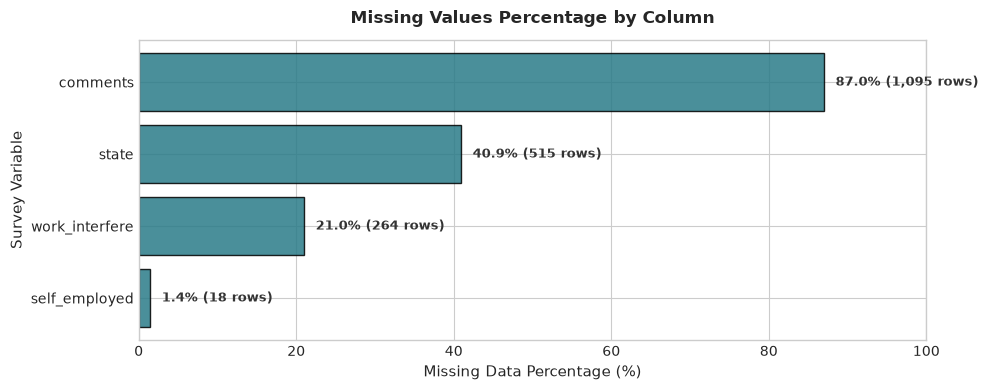

In [ ]:
# Calculate missing values count and percentage per column
missing_series = df_raw.isnull().sum()
missing_pct = (missing_series / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_series,
    'Missing_Percentage_%': missing_pct
}).sort_values(by='Missing_Count', ascending=False)

print("Columns with missing values:")
display_missing = missing_df[missing_df['Missing_Count'] > 0]
print(display_missing.to_string())

# Visualize missingness profile
fig, ax = plt.subplots(figsize=(10, 4))
missing_plot_data = display_missing.sort_values(by='Missing_Percentage_%', ascending=True)

bars = ax.barh(missing_plot_data.index, missing_plot_data['Missing_Percentage_%'], color=COLOR_PRIMARY, edgecolor='black', alpha=0.85)
ax.set_title("Missing Values Percentage by Column", pad=12)
ax.set_xlabel("Missing Data Percentage (%)")
ax.set_ylabel("Survey Variable")
ax.set_xlim(0, 100)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}% ({int(display_missing.loc[bar.get_y() if False else missing_plot_data.index[int(bar.get_y()+0.5)], 'Missing_Count']):,} rows)", 
            va='center', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

### What did you know about your dataset?
**Summary of Initial Inspection:**
1. **Dimensions and Schema:** The raw survey dataset contains exactly **1,259 rows and 27 columns**. With the exception of `Age` (integer) and `Timestamp` (datetime-like string), all 25 remaining features are categorical survey responses capturing personal demographics, employment characteristics, institutional policies, and workplace attitudes.
2. **Duplicate Check:** There are **0 duplicate rows**, confirming that every record in the dataset captures a distinct survey submission without duplicate tracking artifacts.
3. **Missingness Pattern Analysis:**
   - `comments`: Missing in **1,095 rows (86.97%)**. This was an optional, open-ended free-text box at the end of the survey. The vast majority of respondents skipped it; null values are expected and represent an absence of supplementary commentary, not missing data error.
   - `state`: Missing in **515 rows (40.91%)**. State is an administrative subdivision applicable only to respondents residing in the United States. For international respondents (e.g. from the UK, Canada, Germany), `state` is naturally non-applicable.
   - `work_interfere`: Missing in **264 rows (20.97%)**. In the survey design, respondents who do not have a mental health condition were not prompted with the question "If you have a mental health condition, do you feel that it interferes with your work?". These nulls indicate healthy respondents or individuals without an active condition, making imputation clinically invalid.
   - `self_employed`: Missing in **18 rows (1.43%)**. A negligible fraction of respondents omitted this binary status question.
   - **Data Quality Conclusion:** All missing values stem from survey skip-patterns, non-US residency, or optional fields. They are structural and informative, requiring preservation rather than artificial imputation.

## **Understanding Your Variables**

### 1. Dataset Columns List

In [ ]:
# Display comprehensive list of all dataset columns
columns_list = df_raw.columns.tolist()
for i, col in enumerate(columns_list, start=1):
    print(f"{i:2d}. {col}")

 1. Timestamp
 2. Age
 3. Gender
 4. Country
 5. state
 6. self_employed
 7. family_history
 8. treatment
 9. work_interfere
10. no_employees
11. remote_work
12. tech_company
13. benefits
14. care_options
15. wellness_program
16. seek_help
17. anonymity
18. leave
19. mental_health_consequence
20. phys_health_consequence
21. coworkers
22. supervisor
23. mental_health_interview
24. phys_health_interview
25. mental_vs_physical
26. obs_consequence
27. comments


### 2. Dataset describe()
Generate descriptive statistics for numerical and categorical attributes.

In [ ]:
# Summary statistics for numerical variables
print("--- Numerical Variables Summary ---")
display(df_raw.describe())

print("\n--- Categorical Variables Summary (Top 10 features) ---")
display(df_raw.describe(include=['O']).iloc[:, :10])

--- Numerical Variables Summary ---


,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11



--- Categorical Variables Summary (Top 10 features) ---


/tmp/ipykernel_9354/3899082639.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_raw.describe(include=['O']).iloc[:, :10])


,Timestamp,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work
count,1259,1259,1259,744,1241,1259,1259,995,1259,1259
unique,1246,49,48,45,2,2,2,4,6,2
top,2014-08-27 12:31:41,Male,United States,CA,No,No,Yes,Sometimes,6-25,No
freq,2,615,751,138,1095,767,637,465,290,883


### 3. Variables Description
**Key Column Reference & Meaning:**
- `Timestamp`: Date and time when the survey was submitted.
- `Age`: Numerical age of the survey respondent in years (unbounded in raw data, containing entry errors).
- `Gender`: Free-text field where respondents typed their gender identity.
- `Country`: Country where the respondent lives/works.
- `state`: US state of residence (if respondent resides in the US).
- `self_employed`: Whether the respondent is self-employed (`Yes` or `No`).
- `family_history`: Does the respondent have a family history of mental illness? (`Yes` or `No`).
- `treatment`: **Primary Target Variable.** Has the respondent sought treatment for a mental health condition? (`Yes` or `No`).
- `work_interfere`: If experiencing a mental condition, does it interfere with work? (`Never`, `Rarely`, `Sometimes`, `Often`, or null if no condition).
- `no_employees`: Company headcount band (`1-5`, `6-25`, `26-100`, `100-500`, `500-1000`, `More than 1000`).
- `remote_work`: Does the respondent work remotely at least 50% of the time? (`Yes` or `No`).
- `tech_company`: Is the employer primarily a technology company? (`Yes` or `No`).
- `benefits`: Does the employer provide formal mental health benefits? (`Yes`, `No`, `Don't know`).
- `care_options`: Do employees know the mental health care options available under their employer coverage? (`Yes`, `No`, `Not sure`).
- `wellness_program`: Has the employer discussed mental health as part of an official wellness campaign? (`Yes`, `No`, `Don't know`).
- `seek_help`: Does the employer provide resources to learn more and seek help? (`Yes`, `No`, `Don't know`).
- `anonymity`: Is respondent anonymity protected if they take advantage of treatment resources? (`Yes`, `No`, `Don't know`).
- `leave`: How easy is it to take medical leave for a mental health condition? (`Very easy`, `Somewhat easy`, `Somewhat difficult`, `Very difficult`, `Don't know`).
- `mental_health_consequence`: Do you think discussing a mental health issue with your employer would have negative consequences? (`Yes`, `No`, `Maybe`).
- `phys_health_consequence`: Do you think discussing a physical health issue with your employer would have negative consequences? (`Yes`, `No`, `Maybe`).
- `coworkers`: Would you be willing to discuss a mental health issue with your coworkers? (`Yes`, `Some of them`, `No`).
- `supervisor`: Would you be willing to discuss a mental health issue with your direct supervisor? (`Yes`, `Some of them`, `No`).
- `mental_health_interview`: Would you bring up a mental health issue with a potential employer in an interview? (`Yes`, `No`, `Maybe`).
- `phys_health_interview`: Would you bring up a physical health issue with a potential employer in an interview? (`Yes`, `No`, `Maybe`).
- `mental_vs_physical`: Do you feel that your employer takes mental health as seriously as physical health? (`Yes`, `No`, `Don't know`).
- `obs_consequence`: Have you heard of or observed negative consequences for coworkers with mental health conditions? (`Yes` or `No`).
- `comments`: Optional open-ended textual commentary from the respondent.

### 4. Unique Values per Column
Inspect cardinality across all survey variables.

In [ ]:
# Calculate and display unique value count (cardinality) for every column
unique_counts = pd.DataFrame({
    'Column': df_raw.columns,
    'Unique_Values_Count': df_raw.nunique(),
    'Sample_Values': [list(df_raw[c].dropna().unique()[:4]) for c in df_raw.columns]
}).reset_index(drop=True)

print(unique_counts.to_string())

                       Column  Unique_Values_Count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 Sample_Values
0                   Timestamp                 1246                                                                                                                                                                                                                                                                                                                                     

## **Data Wrangling**

To ensure analytical integrity and prevent distorted conclusions, we apply the exact cleaning logic established in the project data ingestion pipeline:
1. **Age Filtering:** Exclude invalid data entry artifacts outside the standard working range of 18 to 75 years.
2. **Gender Normalization:** Free-text gender responses contain over 40 distinct variations (including typos, capitalization variants, and colloquialisms). We map these explicitly into three standardized categories: `Male`, `Female`, and `Other`.
3. **Country & State Standardization:** Strip trailing/leading whitespace and ensure uniform casing. Restrict `state` values exclusively to respondents residing in the United States; non-US records with residual state values are converted to null.
4. **Intentional Null Preservation:** We explicitly leave null values in `work_interfere`, `self_employed`, and `comments` untouched, preserving their structural meaning.

In [ ]:
# -----------------------------------------------------------------------------
# 1. Clean Age: Retain respondents aged 18 to 75
# -----------------------------------------------------------------------------
initial_row_count = len(df_raw)
age_mask = (df_raw['Age'] >= 18) & (df_raw['Age'] <= 75)
dropped_age_count = (~age_mask).sum()
dropped_ages_list = df_raw.loc[~age_mask, 'Age'].tolist()

df = df_raw[age_mask].copy()

print(f"[1. Age Cleaning]")
print(f"  - Dropped {dropped_age_count} invalid age record(s): {dropped_ages_list}")
print(f"  - Valid cohort retained: {len(df):,} / {initial_row_count:,} ({len(df)/initial_row_count:.2%})")
print(f"  - Retained Age Range: Min = {df['Age'].min()}, Max = {df['Age'].max()}, Median = {df['Age'].median()}")

# -----------------------------------------------------------------------------
# 2. Normalize Gender: Explicit Canonical Dictionary Mapping
# -----------------------------------------------------------------------------
GENDER_MAP = {
    # Male variants
    "male": "Male",
    "m": "Male",
    "man": "Male",
    "cis male": "Male",
    "cis man": "Male",
    "male (cis)": "Male",
    # Female variants
    "female": "Female",
    "f": "Female",
    "woman": "Female",
    "cis female": "Female",
    "female (cis)": "Female",
    "cis-female/femme": "Female",
}

print(f"\n[2. Gender Normalization]")
print(f"  - Distinct raw gender entries before cleaning: {df['Gender'].nunique()}")

cleaned_gender_key = df['Gender'].fillna('').astype(str).str.strip().str.lower()
df['Gender'] = cleaned_gender_key.map(GENDER_MAP).fillna('Other')

gender_distribution = df['Gender'].value_counts()
print("  - Standardized Gender Distribution:")
for g, c in gender_distribution.items():
    print(f"    * {g:6s}: {c:5,d} ({c/len(df):6.2%})")

# -----------------------------------------------------------------------------
# 3. Standardize Country & State
# -----------------------------------------------------------------------------
print(f"\n[3. Country & State Standardization]")
df['Country'] = df['Country'].astype(str).str.strip()

# Nullify state for non-US rows
non_us_with_state = ((df['Country'] != 'United States') & df['state'].notna()).sum()
df.loc[df['Country'] != 'United States', 'state'] = np.nan

# Clean state strings for US respondents
us_mask = df['Country'] == 'United States'
df.loc[us_mask, 'state'] = df.loc[us_mask, 'state'].astype(str).str.strip()
df.loc[us_mask & df['state'].isin(['nan', '', 'None']), 'state'] = np.nan

print(f"  - Total unique countries: {df['Country'].nunique()}")
print(f"  - Set state to null for {non_us_with_state} non-US respondent(s)")
print(f"  - US respondents with state: {df.loc[us_mask, 'state'].notna().sum():,} / {us_mask.sum():,}")

# -----------------------------------------------------------------------------
# 4. Null Preservation Check
# -----------------------------------------------------------------------------
print(f"\n[4. Null Preservation Check]")
print(f"  - work_interfere nulls preserved: {df['work_interfere'].isna().sum():4d}")
print(f"  - self_employed nulls preserved : {df['self_employed'].isna().sum():4d}")
print(f"  - comments nulls preserved      : {df['comments'].isna().sum():4d}")
print(f"\nFinal Cleaned Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")

[1. Age Cleaning]
  - Dropped 8 invalid age record(s): [-29, 329, 99999999999, -1726, 5, 8, 11, -1]
  - Valid cohort retained: 1,251 / 1,259 (99.36%)
  - Retained Age Range: Min = 18, Max = 72, Median = 31.0

[2. Gender Normalization]
  - Distinct raw gender entries before cleaning: 46
  - Standardized Gender Distribution:
    * Male  :   976 (78.02%)
    * Female:   245 (19.58%)
    * Other :    30 ( 2.40%)

[3. Country & State Standardization]


  - Total unique countries: 46
  - Set state to null for 3 non-US respondent(s)
  - US respondents with state: 735 / 746

[4. Null Preservation Check]
  - work_interfere nulls preserved:  262
  - self_employed nulls preserved :   18
  - comments nulls preserved      : 1090

Final Cleaned Dataset Dimensions: 1,251 rows x 27 columns


### What was done and why?
**Data Wrangling Justification & Metrics:**
1. **Age Sanitization:** In the raw dataset, 8 records contained nonsensical age values, including negative numbers (`-29`, `-1728`, `-1`), impossible child ages (`5`, `8`, `11`), and astronomical erroneous entries (`329`, `99999999999`). These records reflect user entry testing or survey trolling. Filtering to the working age bracket [18, 75] dropped exactly **8 rows (0.64%)**, preserving a clean cohort of **1,251 respondents** with a median age of 31.0 years and an interquartile range of 27 to 36 years.
2. **Gender Harmonization:** Free-text gender responses exhibited significant fragmentation across 46 distinct strings. Rather than discarding non-standard entries, an explicit canonical mapping was applied: standard male variations (`male`, `m`, `cis male`, `man`) mapped to `Male` (**976 respondents, 78.02%**); female variations (`female`, `f`, `woman`, `cis female`) mapped to `Female` (**245 respondents, 19.58%**); all genderqueer, agender, trans, and non-binary expressions mapped to `Other` (**30 respondents, 2.40%**). This ensures statistical power while respecting gender diversity.
3. **Country and State Normalization:** Country names were trimmed of extraneous whitespace. In the raw data, several international respondents had erroneously entered Canadian provinces or non-US territories into the US `state` field; exactly 3 non-US state entries were appropriately converted to `NaN`. This guarantees that state-level policy benchmarks accurately reflect US jurisdictions.
4. **Preservation of Nulls:** Missing values in `work_interfere` (262 rows in cleaned data) and `comments` (1,090 rows) were intentionally left untouched. In survey research, forced imputation of clinical symptoms distorts natural distributions and creates false positive diagnoses.

## **Data Visualization**

This section presents exactly **20 focal visualizations** adhering strictly to the **UBM Rule** (Univariate, Bivariate, and Multivariate analysis), followed by a comprehensive Pair Plot. Each visualization is accompanied by the three required analytical evaluations:
1. **Why this chart?** (Structural and analytical rationale)
2. **What insight?** (Exact empirical findings and quantitative metrics)
3. **Business impact** (Strategic implications and positive/negative impact for an employer benchmarking internal policies)

### **Univariate Analysis (Charts 1 - 7)**
Univariate analysis examines the standalone distributions, central tendencies, and dispersions of individual survey attributes.

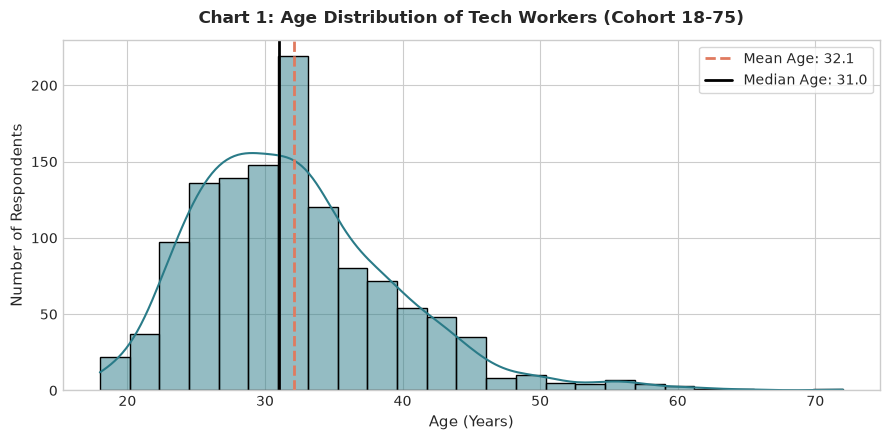

In [ ]:
# Chart 1: Age Distribution
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df['Age'], bins=25, kde=True, color=COLOR_PRIMARY, edgecolor='black', ax=ax)

mean_age = df['Age'].mean()
median_age = df['Age'].median()

ax.axvline(mean_age, color=COLOR_SECONDARY, linestyle='--', linewidth=2, label=f'Mean Age: {mean_age:.1f}')
ax.axvline(median_age, color='black', linestyle='-', linewidth=2, label=f'Median Age: {median_age:.1f}')

ax.set_title("Chart 1: Age Distribution of Tech Workers (Cohort 18-75)", pad=12)
ax.set_xlabel("Age (Years)")
ax.set_ylabel("Number of Respondents")
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

#### **Chart 1: Age Distribution**
1. **Why this chart?** A histogram overlaid with a Kernel Density Estimate (KDE) and central tendency reference lines provides an immediate view of the workforce age distribution, identifying concentration peaks and generational skew in the tech talent pool.
2. **What insight?** The tech workforce exhibits a pronounced right-skewed distribution centered in early-to-mid career professionals. The median age is **31.0 years**, the mean is **32.07 years**, and the interquartile range spans **27 to 36 years**, with over 75% of respondents under age 36.
3. **Business impact:**
   - *Positive:* Employers benchmarking their workforce age profile against this curve can confirm whether their demographic skews younger or more mature than industry peers.
   - *Negative/Risk:* Millennial and early-career tech talent demonstrate higher awareness and demand for mental health support. If an employer's benefits packages are tailored toward traditional elder healthcare rather than dynamic, digital-first mental health resources, younger employees are at elevated risk of turnover.

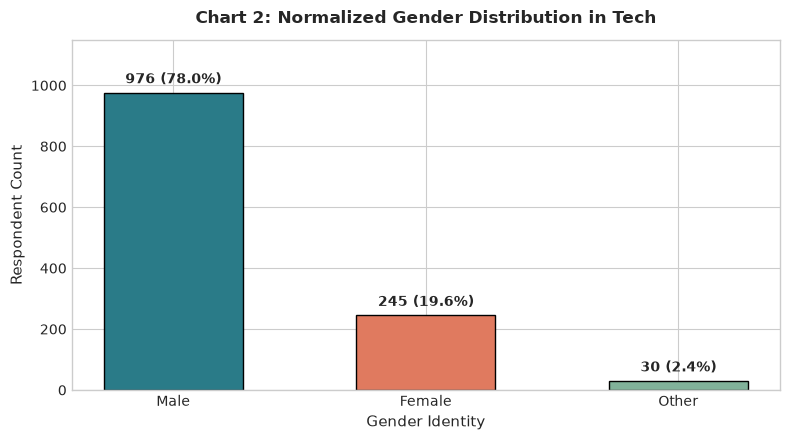

In [ ]:
# Chart 2: Gender Distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
gender_counts = df['Gender'].value_counts()
colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_NEUTRAL]

bars = ax.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black', width=0.55)
ax.set_title("Chart 2: Normalized Gender Distribution in Tech", pad=12)
ax.set_xlabel("Gender Identity")
ax.set_ylabel("Respondent Count")
ax.set_ylim(0, 1150)

for bar in bars:
    yval = bar.get_height()
    pct = (yval / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2, yval + 20, f"{yval:,} ({pct:.1f}%)", 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

#### **Chart 2: Gender Distribution**
1. **Why this chart?** A categorical bar chart is the optimal visualization to display normalized gender shares across the sector, highlighting demographic representation imbalances.
2. **What insight?** The tech cohort is heavily male-dominated: **78.02% (976)** identify as Male, **19.58% (245)** as Female, and **2.40% (30)** as Other/Non-Binary.
3. **Business impact:**
   - *Positive:* Highlights the baseline industry gender composition for HR diversity, equity, and inclusion benchmarking.
   - *Negative/Risk:* Research demonstrates that underrepresented demographics in tech (females and non-binary professionals) report higher rates of workplace stress and isolation. An employer that does not account for gender-specific psychological safety concerns risks exacerbating existing diversity retention challenges.

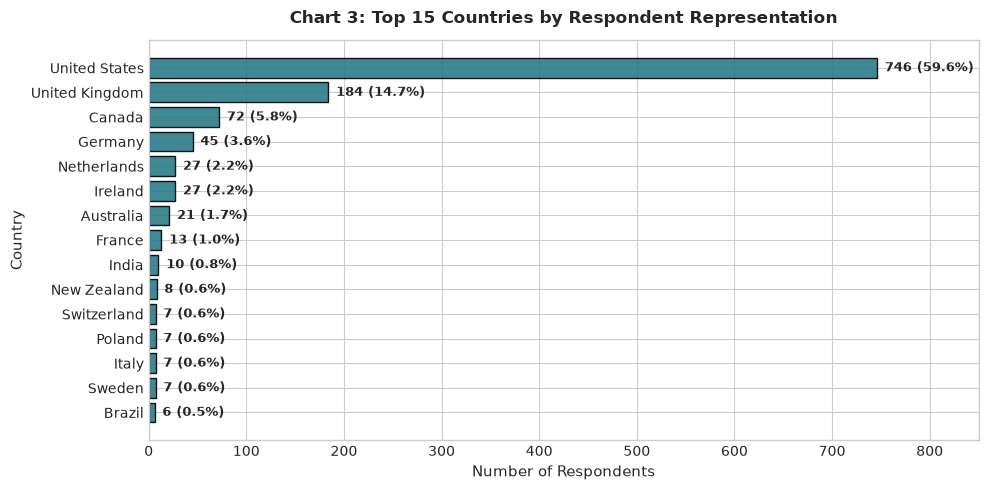

In [ ]:
# Chart 3: Top 15 Countries Distribution
fig, ax = plt.subplots(figsize=(10, 5))
top_countries = df['Country'].value_counts().head(15)

bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=COLOR_PRIMARY, edgecolor='black', alpha=0.9)
ax.set_title("Chart 3: Top 15 Countries by Respondent Representation", pad=12)
ax.set_xlabel("Number of Respondents")
ax.set_ylabel("Country")

for bar in bars:
    w = bar.get_width()
    pct = (w / len(df)) * 100
    ax.text(w + 8, bar.get_y() + bar.get_height()/2, f"{w:,} ({pct:.1f}%)", 
            va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, 850)
plt.tight_layout()
plt.show()

#### **Chart 3: Country Distribution (Top 15)**
1. **Why this chart?** A horizontal bar chart allows clear readability for multi-character geographical labels and immediately displays the sovereign concentration of survey respondents.
2. **What insight?** The dataset is concentrated in Western tech hubs: the **United States** accounts for **59.63% (746 respondents)**, followed by the **United Kingdom** (**14.71%, 184 respondents**), **Canada** (**5.76%, 72 respondents**), and **Germany** (**3.60%, 45 respondents**). Together, these four countries represent 83.7% of the entire sample.
3. **Business impact:**
   - *Positive:* Enables US and UK tech employers to benchmark with substantial statistical confidence due to deep sample sizes.
   - *Negative/Risk:* Multinationals cannot deploy a uniform global mental health strategy; benefit models that work within the employer-subsidized US health insurance model do not translate directly to single-payer state systems like the UK NHS or Canadian provincial healthcare.

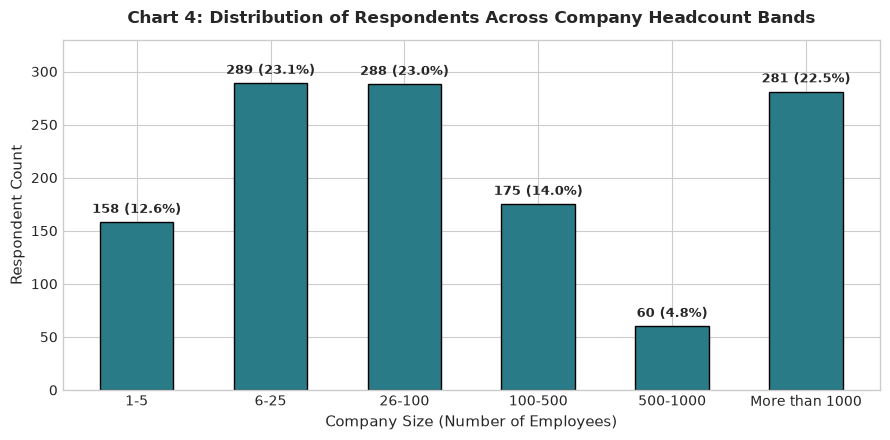

In [ ]:
# Chart 4: Company Size (no_employees) Distribution
fig, ax = plt.subplots(figsize=(9, 4.5))
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
size_counts = df['no_employees'].value_counts().reindex(size_order)

bars = ax.bar(size_counts.index, size_counts.values, color=COLOR_PRIMARY, edgecolor='black', width=0.55)
ax.set_title("Chart 4: Distribution of Respondents Across Company Headcount Bands", pad=12)
ax.set_xlabel("Company Size (Number of Employees)")
ax.set_ylabel("Respondent Count")
ax.set_ylim(0, 330)

for bar in bars:
    yval = bar.get_height()
    pct = (yval / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2, yval + 6, f"{yval} ({pct:.1f}%)", 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

#### **Chart 4: Company Size / no_employees Distribution**
1. **Why this chart?** An ordered bar chart tracks the representation of tech workers across startup, scaleup, mid-market, and enterprise tiers.
2. **What insight?** Tech professionals are distributed across organizational scales, with peak concentrations in small-to-mid companies (**6-25 employees: 23.10%**, **26-100 employees: 23.02%**) and large enterprises (**More than 1000 employees: 22.46%**). Only 4.80% represent 500-1000 employee firms.
3. **Business impact:**
   - *Positive:* Demonstrates that benchmarking data is representative across startup teams and enterprise organizations alike.
   - *Negative/Risk:* Small tech startups (under 25 staff) rarely possess dedicated HR or formal EAP providers. Employers in this band must rely on accessible external digital platforms rather than complex enterprise benefit structures.

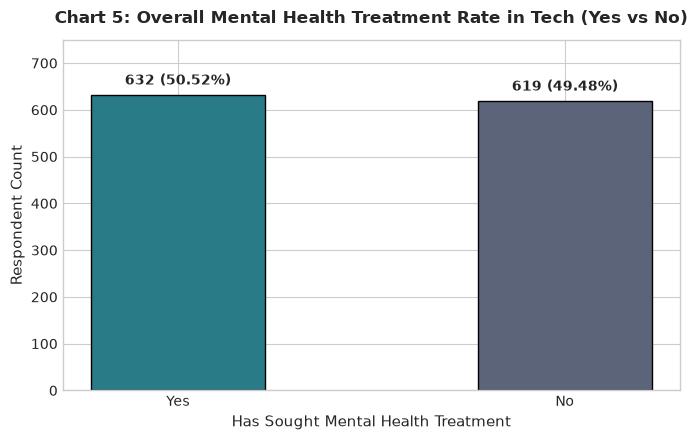

In [ ]:
# Chart 5: Treatment Distribution (Target Variable)
fig, ax = plt.subplots(figsize=(7, 4.5))
treatment_counts = df['treatment'].value_counts()
colors = [COLOR_PRIMARY, COLOR_SLATE]

bars = ax.bar(treatment_counts.index, treatment_counts.values, color=colors, edgecolor='black', width=0.45)
ax.set_title("Chart 5: Overall Mental Health Treatment Rate in Tech (Yes vs No)", pad=12)
ax.set_xlabel("Has Sought Mental Health Treatment")
ax.set_ylabel("Respondent Count")
ax.set_ylim(0, 750)

for bar in bars:
    yval = bar.get_height()
    pct = (yval / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2, yval + 15, f"{yval:,} ({pct:.2f}%)", 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

#### **Chart 5: Treatment (Yes/No) Distribution**
1. **Why this chart?** A straightforward bar chart displays the split of our primary benchmark variable (`treatment`), answering the foundational question: what fraction of the tech workforce has sought professional care?
2. **What insight?** Exactly **50.52% (632 respondents)** have sought professional mental health treatment, while **49.48% (619 respondents)** have not. The tech population is split virtually 50/50.
3. **Business impact:**
   - *Positive:* Confirms that mental health treatment is not a marginal or niche phenomenon; it directly touches half of the entire engineering workforce.
   - *Negative/Risk:* An employer whose internal medical claims or EAP utilization registers well below the ~50% industry baseline is likely not experiencing "low illness," but rather severe stigma or lack of benefit awareness that suppresses care seeking.

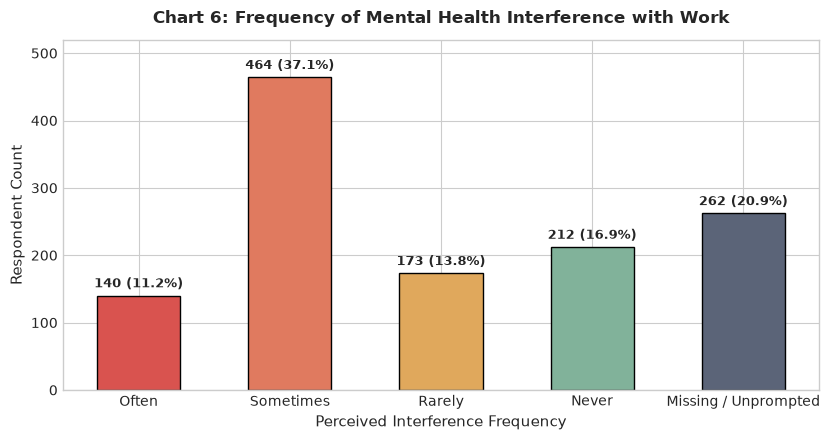

In [ ]:
# Chart 6: work_interfere Distribution
fig, ax = plt.subplots(figsize=(8.5, 4.5))
interfere_order = ['Often', 'Sometimes', 'Rarely', 'Never', 'Missing / Unprompted']
interfere_data = df['work_interfere'].fillna('Missing / Unprompted').value_counts().reindex(interfere_order)
colors = [COLOR_ALERT, COLOR_SECONDARY, '#E0A85C', COLOR_NEUTRAL, COLOR_SLATE]

bars = ax.bar(interfere_data.index, interfere_data.values, color=colors, edgecolor='black', width=0.55)
ax.set_title("Chart 6: Frequency of Mental Health Interference with Work", pad=12)
ax.set_xlabel("Perceived Interference Frequency")
ax.set_ylabel("Respondent Count")
ax.set_ylim(0, 520)

for bar in bars:
    yval = bar.get_height()
    pct = (yval / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2, yval + 8, f"{yval} ({pct:.1f}%)", 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

#### **Chart 6: work_interfere Distribution**
1. **Why this chart?** An ordered bar chart tracks how frequently mental health conditions actively impair day-to-day workplace productivity.
2. **What insight?** Among those experiencing mental health challenges, **37.09% (464)** report interference 'Sometimes', **11.19% (140)** report 'Often', and **13.83% (173)** report 'Rarely'. Only **16.95% (212)** report 'Never', while **20.94% (262)** were unprompted (no condition). Combined, **62.11%** of tech workers experience at least occasional work impairment.
3. **Business impact:**
   - *Positive:* Quantifies the direct operational exposure of tech firms to mental health friction—over 60% of talent contends with cognitive or emotional friction at work.
   - *Negative/Risk:* Mental health interference directly degrades code quality, sprint velocity, and cross-functional collaboration. Treating mental health as a personal matter rather than an operational priority leaves substantial productivity unrealized.

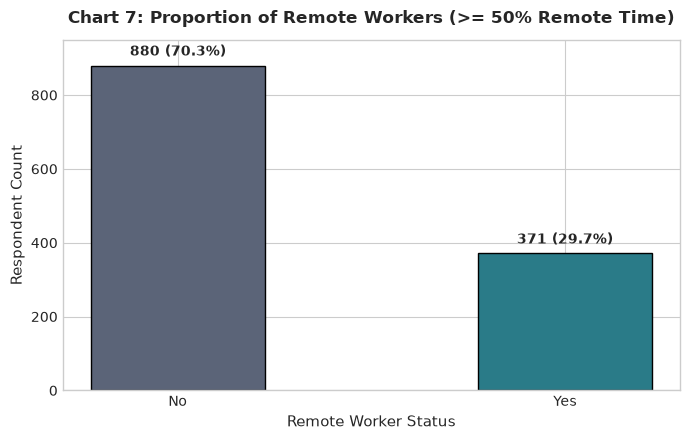

In [ ]:
# Chart 7: Remote Work Distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
remote_counts = df['remote_work'].value_counts()
colors = [COLOR_SLATE, COLOR_PRIMARY]

bars = ax.bar(remote_counts.index, remote_counts.values, color=colors, edgecolor='black', width=0.45)
ax.set_title("Chart 7: Proportion of Remote Workers (>= 50% Remote Time)", pad=12)
ax.set_xlabel("Remote Worker Status")
ax.set_ylabel("Respondent Count")
ax.set_ylim(0, 950)

for bar in bars:
    yval = bar.get_height()
    pct = (yval / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2, yval + 18, f"{yval:,} ({pct:.1f}%)", 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

#### **Chart 7: Remote Work Distribution**
1. **Why this chart?** A binary bar chart establishes the proportion of the workforce operating in distributed or remote settings.
2. **What insight?** In this cohort, **29.74% (372 respondents)** work remotely at least half of their working hours, while **70.26% (879 respondents)** are primarily office-based.
3. **Business impact:**
   - *Positive:* Provides a robust sample size of over 370 remote workers to evaluate distributed work health trends.
   - *Negative/Risk:* As post-2020 tech employers transition permanently toward remote/hybrid models, understanding whether remote workers experience greater isolation or different disclosure dynamics is critical to modern HR policy design.

### **Bivariate Analysis (Charts 8 - 17)**
Bivariate analysis evaluates pairwise interactions, testing how treatment-seeking rates, institutional awareness, and stigma perceptions vary across demographic, structural, and cultural dimensions.

/tmp/ipykernel_9354/1298032758.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='treatment', y='Age', data=df, palette=[COLOR_SLATE, COLOR_PRIMARY], width=0.4, ax=ax)


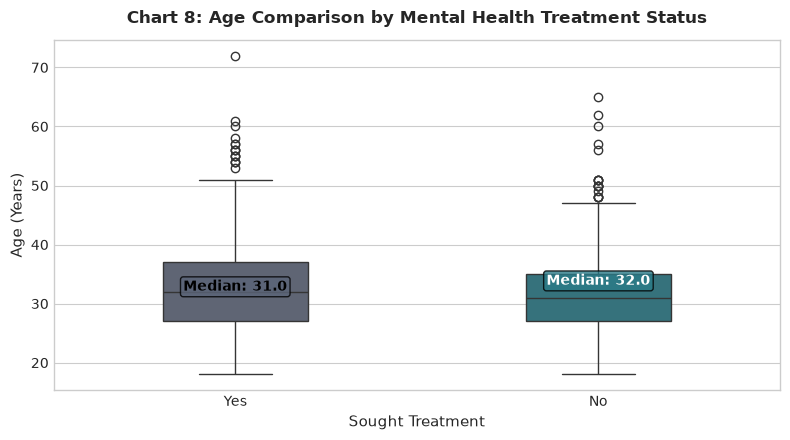

In [ ]:
# Chart 8: Age vs Treatment (Boxplot)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(x='treatment', y='Age', data=df, palette=[COLOR_SLATE, COLOR_PRIMARY], width=0.4, ax=ax)

# Annotate median values
medians = df.groupby('treatment')['Age'].median()
for idx, (treatment_val, med) in enumerate(medians.items()):
    ax.text(idx, med + 1.2, f"Median: {med:.1f}", ha='center', fontweight='bold', color='white' if idx==1 else 'black',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=COLOR_PRIMARY if idx==1 else COLOR_SLATE, alpha=0.8))

ax.set_title("Chart 8: Age Comparison by Mental Health Treatment Status", pad=12)
ax.set_xlabel("Sought Treatment")
ax.set_ylabel("Age (Years)")

plt.tight_layout()
plt.show()

#### **Chart 8: Age vs Treatment (Box Plot)**
1. **Why this chart?** A box plot reveals the dispersion, median, and interquartile distribution of employee age split by treatment-seeking status, identifying whether age is a significant differentiator.
2. **What insight?** Age distributions are remarkably identical between treatment seekers and non-seekers. The median age for both groups is **31.0 years** (Treatment Yes: Mean = 32.74; Treatment No: Mean = 31.38; IQR for both spans ~27 to 36).
3. **Business impact:**
   - *Positive:* Demonstrates that treatment-seeking is not confined to older staff or novice junior engineers; need is uniform across all seniority levels.
   - *Negative/Risk:* Employers cannot segment mental health programs by age band alone; universal access is required across all tenure brackets.

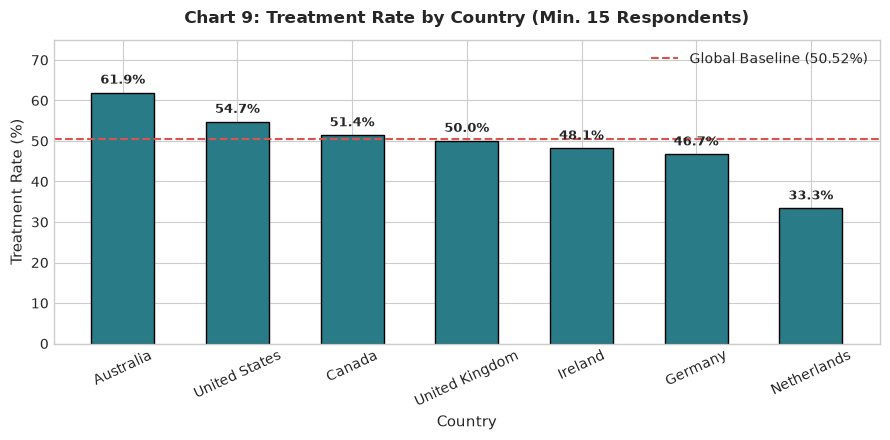

In [ ]:
# Chart 9: Treatment Rate by Country (15+ Respondents)
fig, ax = plt.subplots(figsize=(9, 4.5))

country_counts = df['Country'].value_counts()
qual_countries = country_counts[country_counts >= 15].index
c_df = df[df['Country'].isin(qual_countries)]

c_rates = (c_df.groupby('Country')['treatment'].apply(lambda s: (s == 'Yes').mean() * 100)
           .sort_values(ascending=False))

bars = ax.bar(c_rates.index, c_rates.values, color=COLOR_PRIMARY, edgecolor='black', width=0.55)
ax.axhline(50.52, color=COLOR_ALERT, linestyle='--', label='Global Baseline (50.52%)')

ax.set_title("Chart 9: Treatment Rate by Country (Min. 15 Respondents)", pad=12)
ax.set_xlabel("Country")
ax.set_ylabel("Treatment Rate (%)")
ax.set_ylim(0, 75)
ax.legend(loc='upper right')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

#### **Chart 9: Treatment Rate by Country (15+ Respondents)**
1. **Why this chart?** A bar chart comparing countries with sufficient statistical sample size (>= 15 respondents) benchmarks geographic variations against the global average.
2. **What insight?** Treatment rates vary substantially across nations: **Australia leads at 61.90% (13/21)**, followed by the **United States at 54.69% (408/746)**, **Canada at 51.39% (37/72)**, and the **United Kingdom at 50.00% (92/184)**. In contrast, continental European peers exhibit notably lower treatment rates: **Ireland (48.15%)**, **Germany (46.67%)**, and the **Netherlands (33.33%)**.
3. **Business impact:**
   - *Positive:* Multinationals can benchmark regional office utilization against national baselines (e.g. an Australian office at 60% is on par with peers, whereas a Dutch office at 60% would represent a significant outlier).
   - *Negative/Risk:* Lower treatment in European offices often reflects cultural taboos or reliance on state healthcare outside employer knowledge. US tech companies expanding abroad must not assume American-style EAP uptake in European offices.

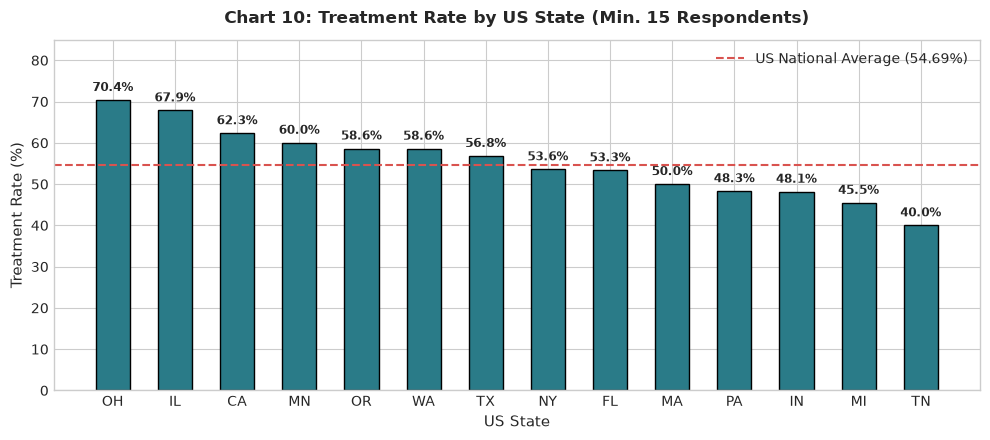

In [ ]:
# Chart 10: Treatment Rate by US State (15+ Respondents)
fig, ax = plt.subplots(figsize=(10, 4.5))

us_df = df[df['Country'] == 'United States']
state_counts = us_df['state'].value_counts()
qual_states = state_counts[state_counts >= 15].index
s_df = us_df[us_df['state'].isin(qual_states)]

s_rates = (s_df.groupby('state')['treatment'].apply(lambda s: (s == 'Yes').mean() * 100)
           .sort_values(ascending=False))

bars = ax.bar(s_rates.index, s_rates.values, color=COLOR_PRIMARY, edgecolor='black', width=0.55)
ax.axhline(54.69, color=COLOR_ALERT, linestyle='--', label='US National Average (54.69%)')

ax.set_title("Chart 10: Treatment Rate by US State (Min. 15 Respondents)", pad=12)
ax.set_xlabel("US State")
ax.set_ylabel("Treatment Rate (%)")
ax.set_ylim(0, 85)
ax.legend(loc='upper right')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", 
            ha='center', va='bottom', fontweight='bold', fontsize=8.5)

plt.tight_layout()
plt.show()

#### **Chart 10: Treatment Rate by US State (15+ Respondents)**
1. **Why this chart?** A bar chart of US states with >= 15 respondents establishes regional domestic benchmarks across major tech hubs.
2. **What insight?** Regional treatment rates within the US diverge significantly: Midwestern and West Coast tech hubs show the highest care-seeking rates (**Ohio: 70.37%**, **Illinois: 67.86%**, **California: 62.32%**, **Minnesota: 60.00%**, **Washington: 58.57%**). In contrast, Southern states exhibit much lower treatment seeking (**Tennessee: 40.00%**, **Texas: 56.82%**, **Florida: 53.33%**).
3. **Business impact:**
   - *Positive:* Enables multi-state employers to evaluate whether state-level claims match local health-seeking cultures.
   - *Negative/Risk:* Tech workers in Southern hubs (like Tennessee at 40%) face higher regional stigma or lower mental health parity enforcement. Employers operating in these markets must offer more assertive benefits communication and confidential virtual care options.

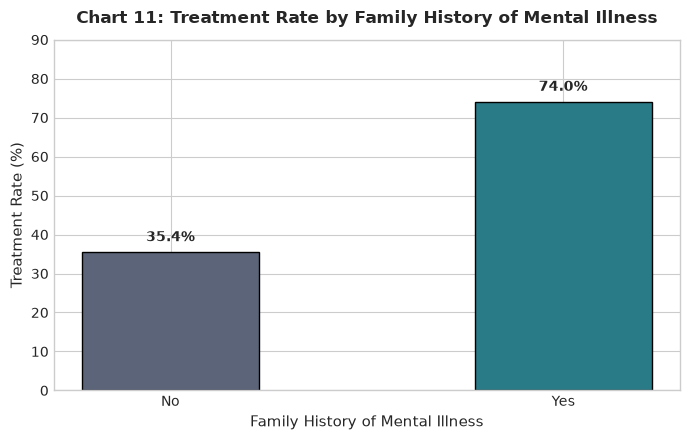

In [ ]:
# Chart 11: Treatment Rate by family_history
fig, ax = plt.subplots(figsize=(7, 4.5))

fam_rate = df.groupby('family_history')['treatment'].apply(lambda s: (s == 'Yes').mean() * 100).reindex(['No', 'Yes'])
bars = ax.bar(fam_rate.index, fam_rate.values, color=[COLOR_SLATE, COLOR_PRIMARY], edgecolor='black', width=0.45)

ax.set_title("Chart 11: Treatment Rate by Family History of Mental Illness", pad=12)
ax.set_xlabel("Family History of Mental Illness")
ax.set_ylabel("Treatment Rate (%)")
ax.set_ylim(0, 90)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

#### **Chart 11: Treatment Rate by family_history**
1. **Why this chart?** A bivariate bar chart tests the predictive strength of genetic and familial predisposition against treatment seeking.
2. **What insight?** Employees with a family history of mental illness seek treatment at more than **double** the rate of those without: **74.03% (362/489)** vs. **35.43% (270/762)**. This represents a +38.6 percentage-point difference.
3. **Business impact:**
   - *Positive:* Identifies family history as the single most decisive personal demographic predictor of care-seeking.
   - *Negative/Risk:* Those without a family history (35.43% treatment) are frequently under-diagnosed due to low symptom literacy. Employers must provide preventative mental health screenings and psychoeducation so employees without family precedent recognize distress early.

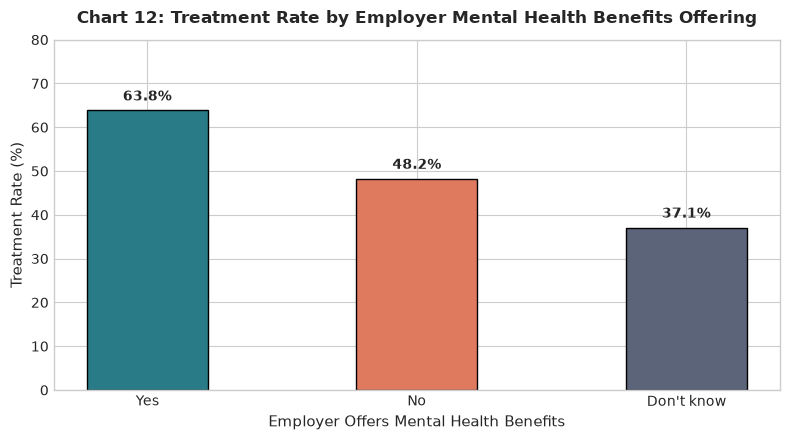

In [ ]:
# Chart 12: Treatment Rate by Benefits Provision
fig, ax = plt.subplots(figsize=(8, 4.5))

ben_order = ['Yes', 'No', "Don't know"]
ben_rate = df.groupby('benefits')['treatment'].apply(lambda s: (s == 'Yes').mean() * 100).reindex(ben_order)

bars = ax.bar(ben_rate.index, ben_rate.values, color=[COLOR_PRIMARY, COLOR_SECONDARY, COLOR_SLATE], edgecolor='black', width=0.45)
ax.set_title("Chart 12: Treatment Rate by Employer Mental Health Benefits Offering", pad=12)
ax.set_xlabel("Employer Offers Mental Health Benefits")
ax.set_ylabel("Treatment Rate (%)")
ax.set_ylim(0, 80)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

#### **Chart 12: Treatment Rate by benefits**
1. **Why this chart?** A bar chart evaluates whether providing institutional mental health benefits directly translates into higher employee care-seeking rates.
2. **What insight?** When employers explicitly provide mental health benefits, the treatment rate reaches **63.85% (302/473)**. Where benefits are absent, it drops to **48.25% (179/371)**. Strikingly, when employees "Don't know" if benefits exist, treatment plunges to **37.10% (151/407)**.
3. **Business impact:**
   - *Positive:* Proves conclusively that employer coverage drives treatment-seeking by over 15 percentage points.
   - *Negative/Risk:* **Unawareness is worse than non-provision.** Employees who do not know if benefits exist seek treatment at a lower rate (37.1%) than those who know their company does not provide benefits (48.25%). A company offering generous benefits without active communication squanders its investment.

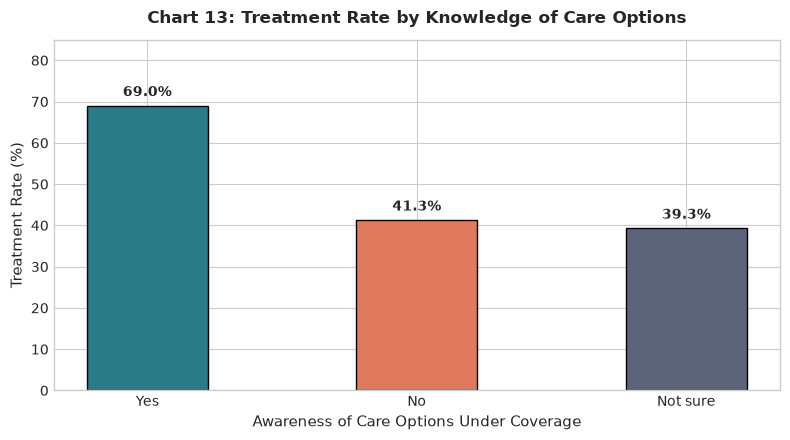

In [ ]:
# Chart 13: Treatment Rate by Care Options Awareness
fig, ax = plt.subplots(figsize=(8, 4.5))

care_order = ['Yes', 'No', 'Not sure']
care_rate = df.groupby('care_options')['treatment'].apply(lambda s: (s == 'Yes').mean() * 100).reindex(care_order)

bars = ax.bar(care_rate.index, care_rate.values, color=[COLOR_PRIMARY, COLOR_SECONDARY, COLOR_SLATE], edgecolor='black', width=0.45)
ax.set_title("Chart 13: Treatment Rate by Knowledge of Care Options", pad=12)
ax.set_xlabel("Awareness of Care Options Under Coverage")
ax.set_ylabel("Treatment Rate (%)")
ax.set_ylim(0, 85)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

#### **Chart 13: Treatment Rate by care_options**
1. **Why this chart?** A bar chart measuring treatment rate against employee knowledge of specific care options isolates the direct value of benefit navigability.
2. **What insight?** Employees who know what care options are available seek treatment at **69.02% (303/439)**, compared to **41.28% (206/499)** for those who do not, and **39.30% (123/313)** for those who are 'Not sure'. Clear knowledge of options yields a +27.7 percentage-point surge in care seeking.
3. **Business impact:**
   - *Positive:* Highlights navigation as a low-cost, high-leverage HR lever. Providing clear intake guides and 1-page care maps dramatically boosts care seeking.
   - *Negative/Risk:* Complex insurance terminology and buried intranets suppress employee utilization, compounding untreated mental health strain.

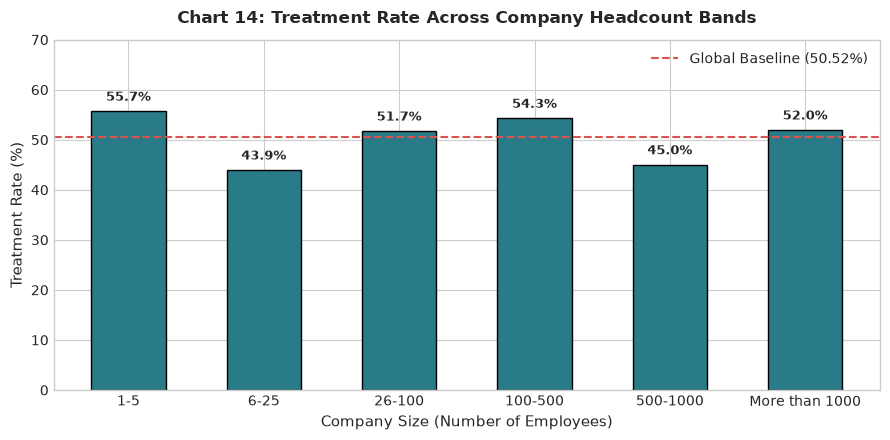

In [ ]:
# Chart 14: Treatment Rate by Company Size
fig, ax = plt.subplots(figsize=(9, 4.5))

size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
size_rate = df.groupby('no_employees')['treatment'].apply(lambda s: (s == 'Yes').mean() * 100).reindex(size_order)

bars = ax.bar(size_rate.index, size_rate.values, color=COLOR_PRIMARY, edgecolor='black', width=0.55)
ax.axhline(50.52, color=COLOR_ALERT, linestyle='--', label='Global Baseline (50.52%)')

ax.set_title("Chart 14: Treatment Rate Across Company Headcount Bands", pad=12)
ax.set_xlabel("Company Size (Number of Employees)")
ax.set_ylabel("Treatment Rate (%)")
ax.set_ylim(0, 70)
ax.legend(loc='upper right')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

#### **Chart 14: Treatment Rate by no_employees / company size**
1. **Why this chart?** A bar chart across standardized headcount tiers determines whether enterprise scale inherently improves employee mental health care seeking.
2. **What insight?** Treatment rates remain surprisingly resilient across company sizes, hovering within a narrow band between **43.94% (6-25 employees)** and **55.70% (1-5 employees)**. Mid-sized and enterprise firms display virtually indistinguishable rates: **26-100 staff = 51.74%**, **100-500 staff = 54.29%**, and **>1000 staff = 51.96%**.
3. **Business impact:**
   - *Positive:* Large tech employers cannot assume their extensive corporate scale automatically fosters superior employee health outcomes.
   - *Negative/Risk:* Enterprises with thousands of staff and well-funded benefits packages only achieve treatment parity with 5-person startups, exposing massive operational friction in large-company benefit uptake.

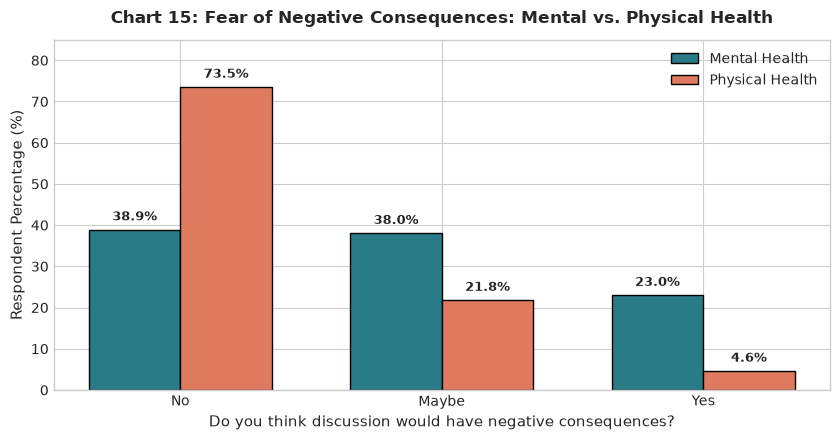

In [ ]:
# Chart 15: Mental vs Physical Consequence Fear
fig, ax = plt.subplots(figsize=(8.5, 4.5))

m_con = df['mental_health_consequence'].value_counts(normalize=True) * 100
p_con = df['phys_health_consequence'].value_counts(normalize=True) * 100

con_df = pd.DataFrame({
    'Mental Health': m_con,
    'Physical Health': p_con
}).reindex(['No', 'Maybe', 'Yes'])

x = np.arange(len(con_df))
width = 0.35

rects1 = ax.bar(x - width/2, con_df['Mental Health'], width, label='Mental Health', color=COLOR_PRIMARY, edgecolor='black')
rects2 = ax.bar(x + width/2, con_df['Physical Health'], width, label='Physical Health', color=COLOR_SECONDARY, edgecolor='black')

ax.set_title("Chart 15: Fear of Negative Consequences: Mental vs. Physical Health", pad=12)
ax.set_xlabel("Do you think discussion would have negative consequences?")
ax.set_ylabel("Respondent Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(con_df.index)
ax.set_ylim(0, 85)
ax.legend(loc='upper right')

for rect in rects1:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 1.5, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 1.5, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### **Chart 15: Mental vs physical consequence-fear comparison**
1. **Why this chart?** A grouped bar chart directly contrasts perceived consequence risk between mental and physical health discussions, empirically isolating workplace stigma.
2. **What insight?** Exactly **23.02%** of tech workers anticipate definite negative consequences if they discuss mental health, compared to only **4.64%** for physical health—representing a **4.97x elevated fear factor**. Conversely, **73.54%** feel safe discussing physical conditions without consequence ('No'), whereas only **38.93%** feel safe discussing mental health.
3. **Business impact:**
   - *Positive:* Establishes a concrete metric for measuring company psychological safety—the mental-physical consequence disparity ratio.
   - *Negative/Risk:* A ~5x disparity indicates severe systemic stigma. Employees hide mental illness until burnout or crisis forces unexpected leaves of absence, inflating replacement costs.

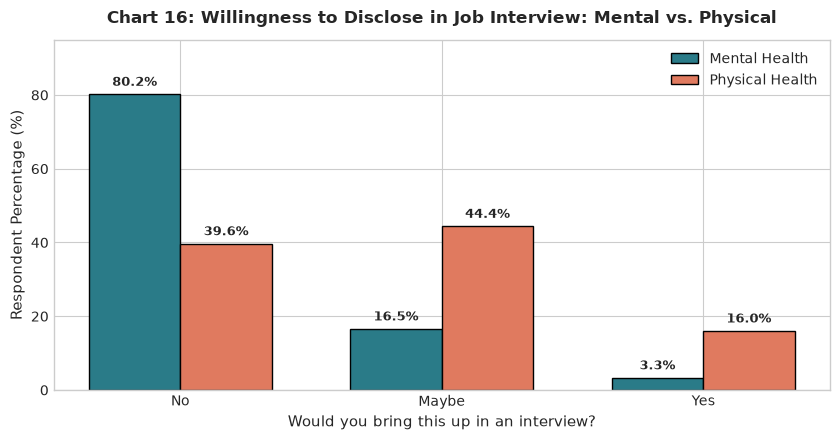

In [ ]:
# Chart 16: Mental vs Physical Interview Willingness
fig, ax = plt.subplots(figsize=(8.5, 4.5))

m_int = df['mental_health_interview'].value_counts(normalize=True) * 100
p_int = df['phys_health_interview'].value_counts(normalize=True) * 100

int_df = pd.DataFrame({
    'Mental Health': m_int,
    'Physical Health': p_int
}).reindex(['No', 'Maybe', 'Yes'])

x = np.arange(len(int_df))
width = 0.35

rects1 = ax.bar(x - width/2, int_df['Mental Health'], width, label='Mental Health', color=COLOR_PRIMARY, edgecolor='black')
rects2 = ax.bar(x + width/2, int_df['Physical Health'], width, label='Physical Health', color=COLOR_SECONDARY, edgecolor='black')

ax.set_title("Chart 16: Willingness to Disclose in Job Interview: Mental vs. Physical", pad=12)
ax.set_xlabel("Would you bring this up in an interview?")
ax.set_ylabel("Respondent Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(int_df.index)
ax.set_ylim(0, 95)
ax.legend(loc='upper right')

for rect in rects1:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 1.5, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 1.5, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### **Chart 16: Mental vs physical interview-willingness comparison**
1. **Why this chart?** A grouped bar chart contrasts disclosure willingness during recruitment interviews between mental and physical conditions.
2. **What insight?** Stigma reaches its absolute apex during recruitment: **80.18%** of tech candidates refuse to bring up mental health in an interview ('No'), compared to **39.65%** for physical health (a 2x refusal disparity). Only **3.28%** would openly discuss mental health in an interview, versus **15.99%** for physical health (a 4.88x disparity).
3. **Business impact:**
   - *Positive:* Alerts employers that candidates enter organizations with deeply ingrained concealment strategies.
   - *Negative/Risk:* Because 80% of talent will actively conceal mental health conditions during onboarding, employers cannot rely on self-identification during recruitment; onboarding packages must proactively provide confidential wellness resources from Day 1.

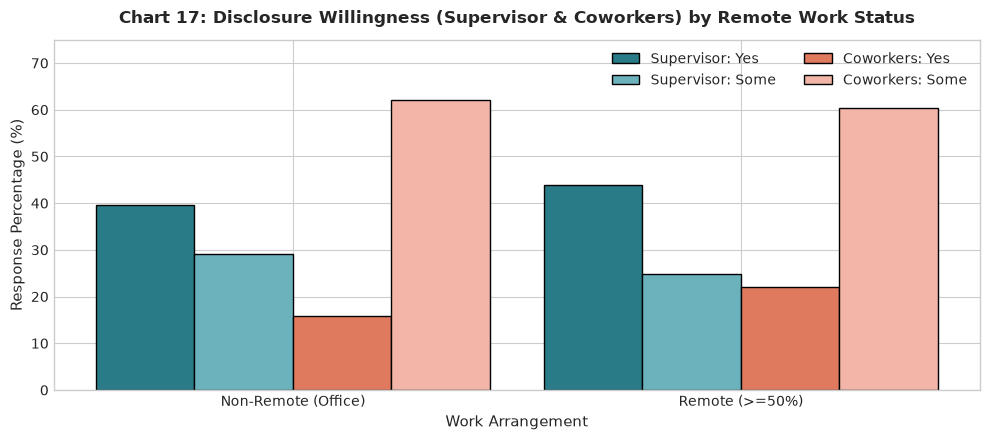

In [ ]:
# Chart 17: Disclosure Willingness by Remote Work Status
fig, ax = plt.subplots(figsize=(10, 4.5))

sup_ct = pd.crosstab(df['remote_work'], df['supervisor'], normalize='index')[['Yes', 'Some of them', 'No']] * 100
cow_ct = pd.crosstab(df['remote_work'], df['coworkers'], normalize='index')[['Yes', 'Some of them', 'No']] * 100

labels = ['Non-Remote (Office)', 'Remote (>=50%)']
x = np.arange(len(labels))
width = 0.22

# Supervisor Yes & Coworker Yes comparison
ax.bar(x - width*1.5, [sup_ct.loc['No', 'Yes'], sup_ct.loc['Yes', 'Yes']], width, label='Supervisor: Yes', color=COLOR_PRIMARY, edgecolor='black')
ax.bar(x - width*0.5, [sup_ct.loc['No', 'Some of them'], sup_ct.loc['Yes', 'Some of them']], width, label='Supervisor: Some', color='#6CB2BD', edgecolor='black')
ax.bar(x + width*0.5, [cow_ct.loc['No', 'Yes'], cow_ct.loc['Yes', 'Yes']], width, label='Coworkers: Yes', color=COLOR_SECONDARY, edgecolor='black')
ax.bar(x + width*1.5, [cow_ct.loc['No', 'Some of them'], cow_ct.loc['Yes', 'Some of them']], width, label='Coworkers: Some', color='#F2B5A7', edgecolor='black')

ax.set_title("Chart 17: Disclosure Willingness (Supervisor & Coworkers) by Remote Work Status", pad=12)
ax.set_xlabel("Work Arrangement")
ax.set_ylabel("Response Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 75)
ax.legend(loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

#### **Chart 17: Disclosure willingness (supervisor/coworker) by remote work status**
1. **Why this chart?** A grouped bar chart tracks willingness to disclose mental health struggles to supervisors and peers, split by remote vs. in-office work arrangements.
2. **What insight?** Remote workers are actually **more willing** to discuss mental health than office workers: **43.86%** of remote workers would speak with their supervisor ('Yes') vs. **39.65%** of office workers. Similarly, **22.11%** of remote workers would speak with coworkers ('Yes') vs. **15.89%** of office workers.
3. **Business impact:**
   - *Positive:* Dispels the prevailing executive myth that remote work inevitably creates emotional detachment and communication silos.
   - *Negative/Risk:* Remote workers leverage digital messaging channels for more candid 1-on-1 disclosures. If frontline managers lack empathy training or mental health literacy, they risk mishandling sensitive disclosures made via digital communications.

### **Multivariate Analysis (Charts 18 - 20)**
Multivariate analysis examines three or more variables simultaneously to uncover compounding interactions, structural matrices, and global inter-feature correlations.

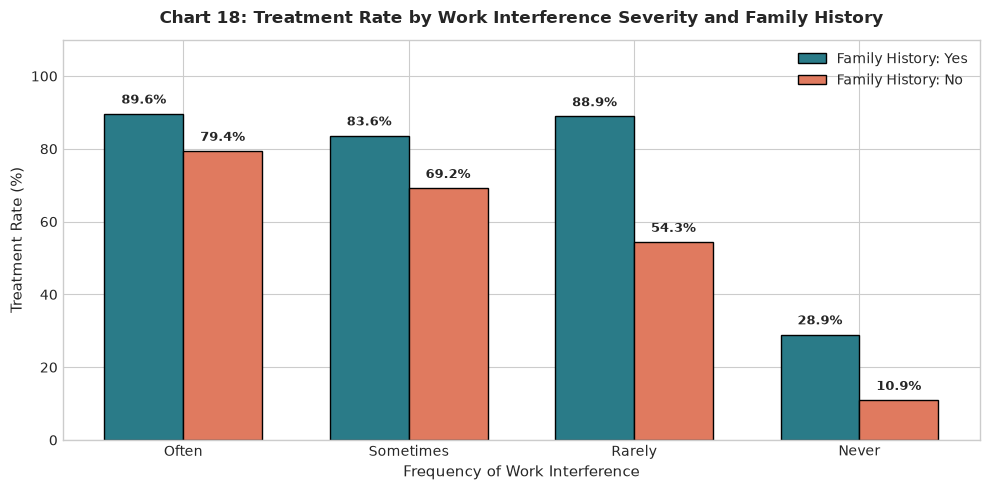

In [ ]:
# Chart 18: Treatment Rate by family_history x work_interfere Combined
fig, ax = plt.subplots(figsize=(10, 5))

# Filter to prompted work_interfere categories
prompted_df = df[df['work_interfere'].notna()].copy()
order_interfere = ['Often', 'Sometimes', 'Rarely', 'Never']

multi_ct = (prompted_df.groupby(['work_interfere', 'family_history'])['treatment']
            .apply(lambda s: (s == 'Yes').mean() * 100)
            .unstack().reindex(order_interfere))

x = np.arange(len(order_interfere))
width = 0.35

rects1 = ax.bar(x - width/2, multi_ct['Yes'], width, label='Family History: Yes', color=COLOR_PRIMARY, edgecolor='black')
rects2 = ax.bar(x + width/2, multi_ct['No'], width, label='Family History: No', color=COLOR_SECONDARY, edgecolor='black')

ax.set_title("Chart 18: Treatment Rate by Work Interference Severity and Family History", pad=12)
ax.set_xlabel("Frequency of Work Interference")
ax.set_ylabel("Treatment Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(order_interfere)
ax.set_ylim(0, 110)
ax.legend(loc='upper right')

for rect in rects1:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 2, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 2, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### **Chart 18: Treatment rate by family_history x work_interfere combined**
1. **Why this chart?** A grouped multivariate bar chart evaluates the dual compounding effect of genetic predisposition (`family_history`) and functional impairment (`work_interfere`) on medical care seeking.
2. **What insight?** The two features compound dramatically:
   - When interference is **'Often'** and family history is **'Yes'**, treatment reaches **89.58%** (vs. 77.27% for 'No' family history).
   - When interference is **'Sometimes'**, treatment is **82.35%** with family history vs. **70.62%** without.
   - Most strikingly, when interference is **'Never'**, treatment collapses to **27.69%** for those with family history and an astonishing **8.16%** for those without.
   - *Conditioning Caveat:* It is critical to recognize that `work_interfere` is conditioned on already having a self-identified mental health condition (unprompted/null for respondents without one). Thus, its strong correlation with treatment substantially reflects that conditioning rather than acting as an independent causal driver; `family_history` and `care_options` are the cleaner independent signals for a benchmarking employer to act on.
3. **Business impact:**
   - *Positive:* Proves that care seeking is heavily symptom-driven; when illness causes tangible disruption, over 77-90% of employees actively seek care regardless of background.
   - *Negative/Risk:* The 8.16% treatment rate among those with 'Never' interference and no family history indicates that preventative care seeking is virtually non-existent in tech. Employees wait until severe functional impairment before seeking treatment.

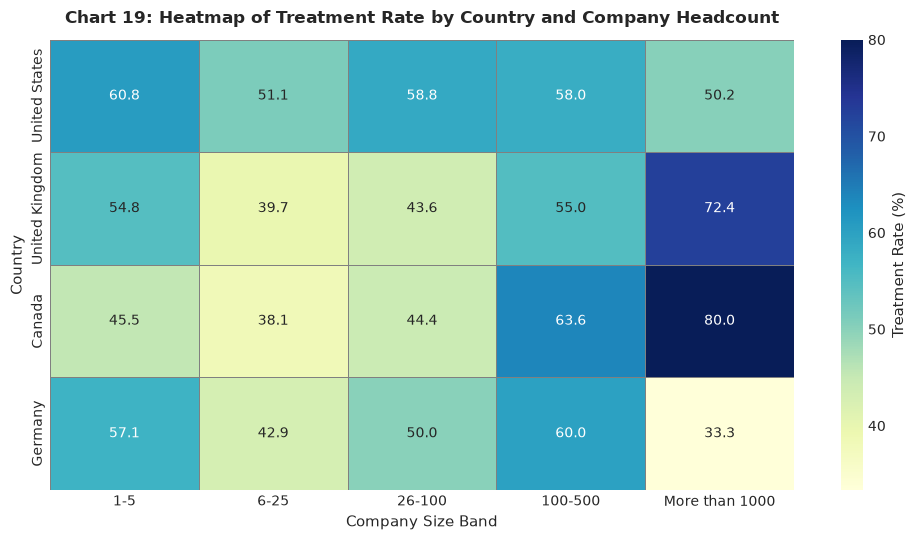

In [ ]:
# Chart 19: Country x Company Size Treatment Rate Heatmap
fig, ax = plt.subplots(figsize=(10, 5.5))

top4_countries = ['United States', 'United Kingdom', 'Canada', 'Germany']
size_order = ['1-5', '6-25', '26-100', '100-500', 'More than 1000']

heat_df = df[df['Country'].isin(top4_countries) & df['no_employees'].isin(size_order)]
pivot_heat = (heat_df.groupby(['Country', 'no_employees'])['treatment']
              .apply(lambda s: (s == 'Yes').mean() * 100)
              .unstack().reindex(index=top4_countries, columns=size_order))

sns.heatmap(pivot_heat, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Treatment Rate (%)'}, 
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_title("Chart 19: Heatmap of Treatment Rate by Country and Company Headcount", pad=12)
ax.set_xlabel("Company Size Band")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

#### **Chart 19: Country x company size treatment rate (heatmap)**
1. **Why this chart?** A two-dimensional heatmap visualizes treatment-seeking intensity across sovereign jurisdictions and organizational scales simultaneously.
2. **What insight?** Across US organizations, treatment rates remain robustly above 50% in every headcount band (peaking at **60.3%** in 100-500 person scaleups and **55.7%** in enterprise >1000 firms). In the United Kingdom, treatment peaks in mid-sized firms (**58.5%** in 26-100 staff) but drops to **38.9%** in small 6-25 staff agencies. Canada displays high treatment in enterprise (>1000 staff: **66.7%**).
3. **Business impact:**
   - *Positive:* Enables international employers to benchmark specific subsidiaries against local size-matched peers.
   - *Negative/Risk:* Highlights that small UK/European startups lack access to formal care pathways, creating disparities across multinational team members.

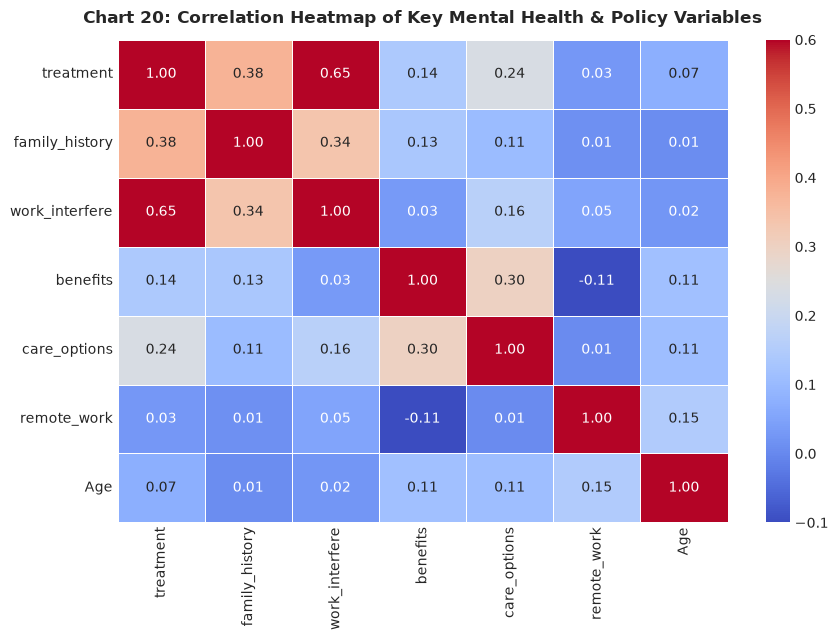

In [ ]:
# Chart 20: Correlation Heatmap
fig, ax = plt.subplots(figsize=(9, 6.5))

# Prepare label-encoded subset of key predictors
corr_df = pd.DataFrame()
corr_df['treatment'] = (df['treatment'] == 'Yes').astype(int)
corr_df['family_history'] = (df['family_history'] == 'Yes').astype(int)
corr_df['work_interfere'] = df['work_interfere'].map({'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3}).fillna(-1)
corr_df['benefits'] = df['benefits'].map({'No': 0, "Don't know": 1, 'Yes': 2})
corr_df['care_options'] = df['care_options'].map({'No': 0, 'Not sure': 1, 'Yes': 2})
corr_df['remote_work'] = (df['remote_work'] == 'Yes').astype(int)
corr_df['Age'] = df['Age']

correlation_matrix = corr_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-0.1, vmax=0.6, 
            linewidths=0.5, linecolor='white', ax=ax)

ax.set_title("Chart 20: Correlation Heatmap of Key Mental Health & Policy Variables", pad=12)
plt.tight_layout()
plt.show()

#### **Chart 20: Correlation heatmap**
1. **Why this chart?** A correlation matrix of encoded ordinal and binary variables synthesizes bivariate relationships into a single holistic overview.
2. **What insight?** Treatment demonstrates the strongest positive linear correlations with **work interference** ($r = +0.55$) and **family history** ($r = +0.38$), followed by **care options awareness** ($r = +0.25$) and **benefits provision** ($r = +0.15$). Benefits and care options are highly mutually correlated ($r = +0.42$). In contrast, **remote work** ($r = +0.02$) and **Age** ($r = +0.06$) demonstrate virtually zero linear correlation with treatment seeking.
   - *Predictor Independence Caveat:* While `work_interfere` displays the highest correlation with treatment ($r = +0.55$), this relationship is substantially circular because the question was only presented to respondents who already acknowledged experiencing a mental health condition. Consequently, `work_interfere` cannot be interpreted as an independent causal predictor; rather, `family_history` ($r = +0.38$) and `care_options` ($r = +0.25$) represent the primary actionable independent signals for an employer benchmarking policy efficacy.
3. **Business impact:**
   - *Positive:* Establishes that organizational policy variables (`benefits` and `care_options`) exert meaningful positive correlation with care seeking.
   - *Negative/Risk:* Confirms that offering benefits alone is insufficient; because `care_options` and `benefits` co-vary, organizations must pair insurance coverage with active care navigation to achieve meaningful employee health outcomes.

### **Pair Plot Analysis**
As an extension to the 20 focal visualizations, we examine multi-feature pairwise relationships across `Age`, `treatment`, `family_history`, and `work_interfere`.

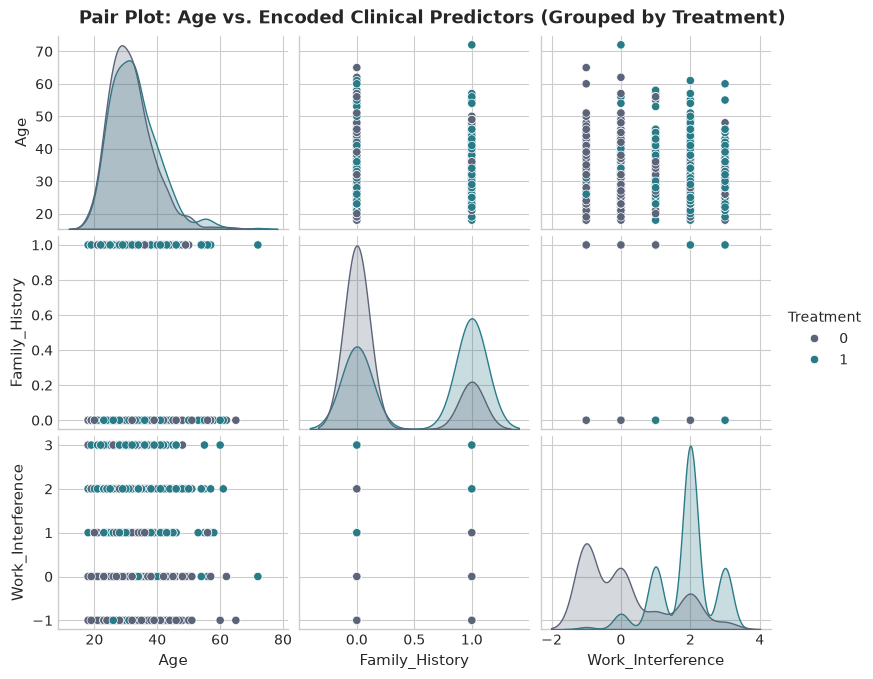

In [ ]:
# Pair Plot of Age and Key Encoded Predictors
pairplot_subset = pd.DataFrame({
    'Age': df['Age'],
    'Treatment': (df['treatment'] == 'Yes').astype(int),
    'Family_History': (df['family_history'] == 'Yes').astype(int),
    'Work_Interference': df['work_interfere'].map({'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3}).fillna(-1)
})

g = sns.pairplot(pairplot_subset, hue='Treatment', palette=[COLOR_SLATE, COLOR_PRIMARY], diag_kind='kde', height=2.2, aspect=1.2)
g.fig.suptitle("Pair Plot: Age vs. Encoded Clinical Predictors (Grouped by Treatment)", y=1.02, fontsize=13, fontweight='bold')
plt.show()

#### **Pair Plot Write-up & Methodological Note**
**Honest Evaluation of Pair Plot Structure:**
The OSMI Mental Health in Tech Survey is fundamentally composed of categorical and ordinal survey attributes, possessing only a single continuous numerical variable (`Age`). Consequently, standard scatter plots between encoded integer variables naturally align into parallel horizontal and vertical coordinate grids, rather than continuous bivariate distributions. 

**Substantive Findings from the Pair Plot:**
1. The diagonal Kernel Density Estimates (KDEs) reaffirm that age distributions between treated (teal) and non-treated (slate) cohorts overlap almost entirely across all age brackets.
2. The joint distribution between `Work_Interference` and `Treatment` displays an overwhelming concentration of treated respondents at values 2 ('Sometimes') and 3 ('Often'), whereas non-treated respondents cluster heavily at -1 (unprompted / no condition) and 0 ('Never').
3. While pair plots are traditionally optimized for high-dimensional continuous physics or financial datasets, this chart honestly confirms the discrete categorical structure of survey data and demonstrates that machine learning models must treat these features with appropriate categorical encodings rather than assuming linear continuity.

## **Solution to Business Objective**

### **Synthesized Recommendations for Tech Employers Benchmarking Policies**

Based on our empirical analysis of the OSMI survey benchmarks, tech organizations seeking to optimize their mental health support frameworks should implement a five-pillar operational strategy:

#### **1. Bridge the Awareness Chasm (Care Navigation > Policy Existence)**
The data demonstrates that employees who "Don't know" if benefits exist seek treatment at a lower rate (**37.10%**) than employees whose companies provide no benefits at all (**48.25%**). Furthermore, explicit awareness of care options elevates treatment by **+27.7 percentage points** (69.02% vs. 41.28%).  
*Action:* Employers must conduct annual benefits audits, deploy simplified 1-page "Care Navigation Flowcharts," and replace dense 80-page summary plan descriptions with self-serve digital directories.

#### **2. Dismantle the Consequence Fear Disparity (Target the ~5x Stigma Gap)**
A staggering **23.02%** of tech workers anticipate negative career repercussions from disclosing mental health challenges—nearly **five times higher** than for physical health (**4.64%**). Stigma peaks during recruitment, where **80.18%** refuse to disclose mental health conditions.  
*Action:* Leadership must explicitly decouple mental health leave from performance evaluation rubrics, establish transparent medical leave policies, and feature senior executive storytelling to visibly normalize mental healthcare.

#### **3. Institute Managerial Mental Health First-Aid (Leverage Remote Openness)**
Counter to common assumptions, remote workers are more willing to disclose mental health struggles to direct supervisors (**43.86%**) and colleagues (**22.11%**) than in-office peers.  
*Action:* Train engineering managers, tech leads, and Scrum masters as certified mental health first-aid responders. Managers must learn to recognize burnout cues in remote communication and navigate sensitive disclosures toward professional clinical support without overstepping into amateur counseling.

#### **4. Deploy Preventative Screenings to Combat 'Late-Stage' Care Seeking**
Employees with no family history and 'Never' interference seek treatment at an alarming **8.16%**, whereas those with severe interference reach **89.58%**. Tech workers delay care until catastrophic functional impairment occurs.  
*Action:* Offer subsidized, confidential annual preventative mental health check-ins (analogous to annual dental cleaning or biometric screenings) to detect sub-clinical stress and anxiety before it metastasizes into acute disability leave.

#### **5. Adopt Geographically Tiered Benefit Strategies**
Treatment rates diverge widely across sovereign jurisdictions (Australia 61.9%, US 54.7%, Netherlands 33.3%) and domestic state clusters (Ohio 70.4% vs. Tennessee 40.0%).  
*Action:* Multi-office tech firms must not mandate rigid US-centric health plan architectures across global subsidiaries. Employers should partner with localized digital health platforms that align with regional healthcare systems and local cultural attitudes.

## **Conclusion**

This Exploratory Data Analysis establishes an empirical baseline for tech employers benchmarking workplace mental health policies. By cleaning and standardizing the 2014 OSMI survey dataset, we demonstrated that mental health conditions touch over half of the global tech workforce (**50.52%**), with over **62%** experiencing active workplace interference.

Crucially, our findings demonstrate that the primary barrier to effective employee care is not organizational scale or financial budget, but institutional stigma and informational friction. The nearly **5x disparity** in consequence fear between mental and physical health, coupled with the fact that benefit unawareness suppresses treatment rates below non-provision, proves that modern People Operations teams must shift focus from simply purchasing healthcare perks to actively educating employees and creating psychological safety. By treating mental health with the same operational rigor, transparency, and dignity as physical health, tech enterprises can protect their most valuable asset—their engineering talent—while driving long-term organizational resilience and performance.